# Day 28: Understanding and Implementing the Naïve Bayes Classifier

---

## 📚 Objective

- Understand the fundamentals of the Naïve Bayes algorithm.
- Implement the Naïve Bayes classifier using Python.
- Apply the classifier to a real-world dataset.
- Visualize the results effectively.

---

## 🔍 Overview of Naïve Bayes

The Naïve Bayes classifier is a probabilistic machine learning model based on Bayes' Theorem. It's particularly useful for classification tasks and is known for its simplicity and efficiency.

**Bayes' Theorem:**

P(A∣B)=P(B∣A)⋅P(A)P(B)P(A∣B)=P(B)P(B∣A)⋅P(A)

In the context of classification:

- P(C∣X)P(C∣X): Posterior probability of class CC given predictor XX.
- P(X∣C)P(X∣C): Likelihood of predictor XX given class CC.
- P(C)P(C): Prior probability of class CC.[Analytics Vidhya+1Learn R, Python & Data Science Online+1](https://www.analyticsvidhya.com/blog/2017/09/naive-bayes-explained/?utm_source=chatgpt.com)
- P(X)P(X): Prior probability of predictor XX.

The "naïve" aspect assumes that all features are independent, which simplifies computation but may not always hold true in real-world data.

---

## 🛠️ Implementation Steps

### 1. Import Libraries


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

### 2. Load and Explore the Dataset

In [4]:
#load iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

In [5]:
#Create DataFrame
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = y 
df['species'] = df['species'].apply(lambda x: iris.target_names[x])

In [6]:
#display first few rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 3. Visualize the Data


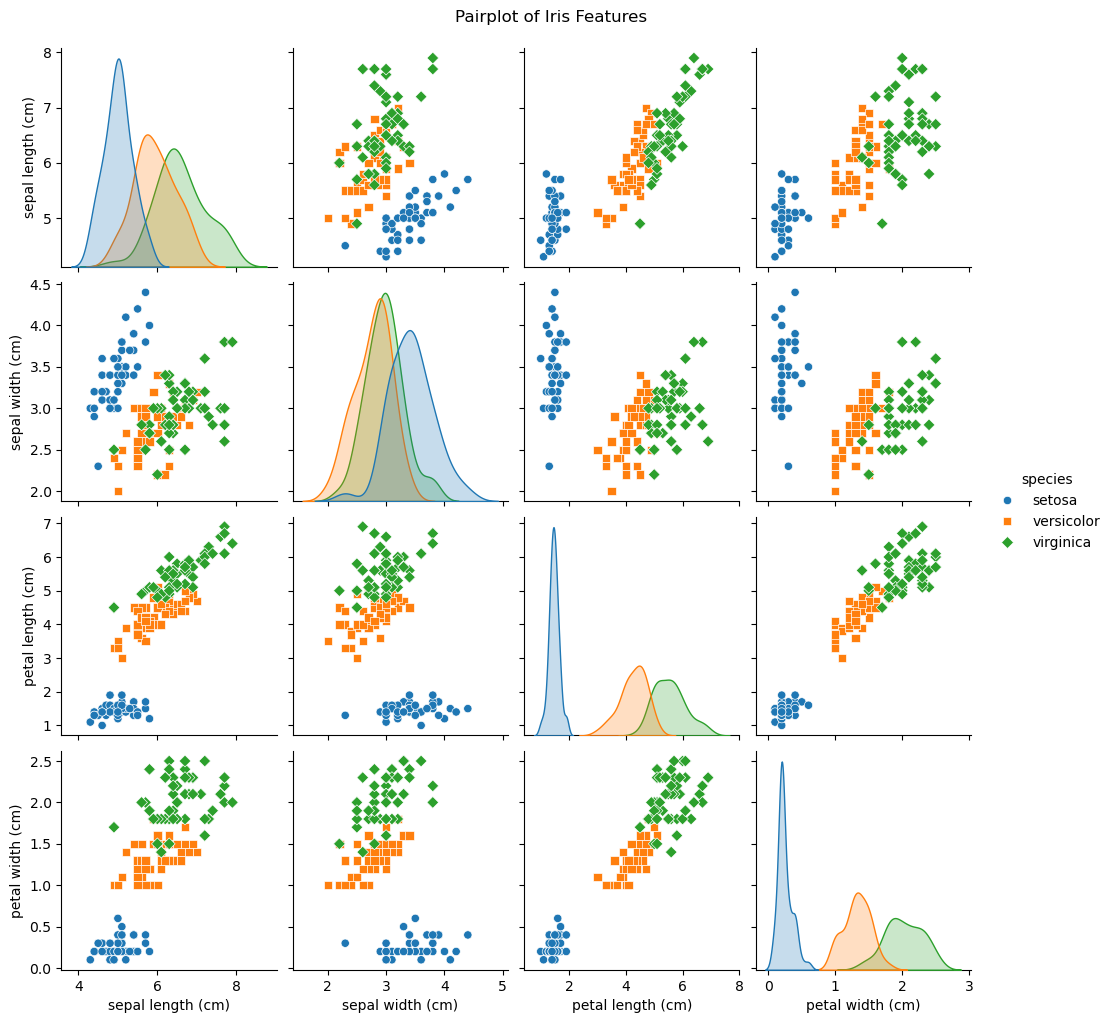

In [7]:
#Pairplot to visualize relationships between features
sns.pairplot(df, hue='species', markers=['o','s','D'])
plt.suptitle('Pairplot of Iris Features', y=1.02)
plt.show()

### 4. Split the Data into Training and Testing Set

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42, stratify=y)

### 5. Train the Naïve Bayes Model

In [9]:
#Initialize the Gaussian Naive Bayes Model
nb_model = GaussianNB()

In [11]:
#Train the model
nb_model.fit(X_train, y_train)

GaussianNB()

### 6. Evaluate the model 

In [12]:
#Predict the test sset
y_pred = nb_model.predict(X_test)

In [13]:
#Classification Report
print('Classification Report:\n', classification_report(y_test, y_pred, target_names=iris.target_names))

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



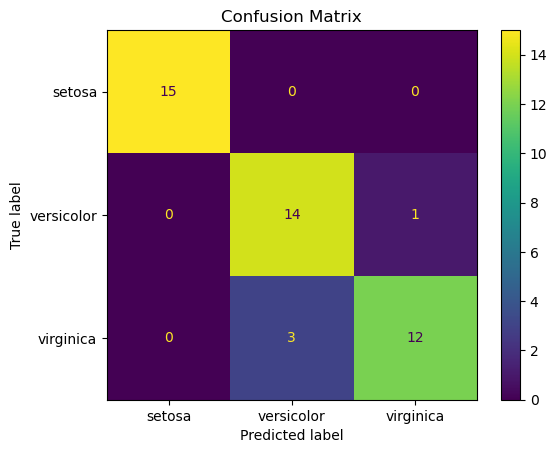

In [14]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap='viridis')
plt.title('Confusion Matrix')
plt.show()

### 7. Visualize Decision Boundaries


In [15]:
#Select two feature for visualization
X_vis = df[['sepal length (cm)', 'petal length (cm)']].values
y_vis = df['species'].apply(lambda x:np.where(iris.target_names == x)[0][0]).values

In [16]:
#Split the data
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(X_vis, y_vis, test_size=0.3, random_state=42, stratify=y_vis)

In [17]:
#Train the model
nb_model_vis = GaussianNB()
nb_model_vis.fit(X_train_vis, y_train_vis)

GaussianNB()

In [18]:
#Function to plot decision boundaries
def plot_decision_boundary(X, y, model, title):
    x_min, x_max =X[:, 0].min() - 1, X[:, 0].max() +1
    y_min, y_max =X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10,6))
    plt.contourf(xx,yy,Z, alpha=0.3, cmap=plt.cm.Paired)
    scatter = plt.scatter(X[:,0], X[:, 1], c=y, s=40, edgecolor='k', cmap=plt.cm.Paired)

    plt.xlabel('Sepal Length (cm)')
    plt.ylabel('Petal Length (cm)')
    plt.title(title)

    handles, _ = scatter.legend_elements()
    plt.legend(handles, iris.target_names, title='Species')
    
    plt.show()

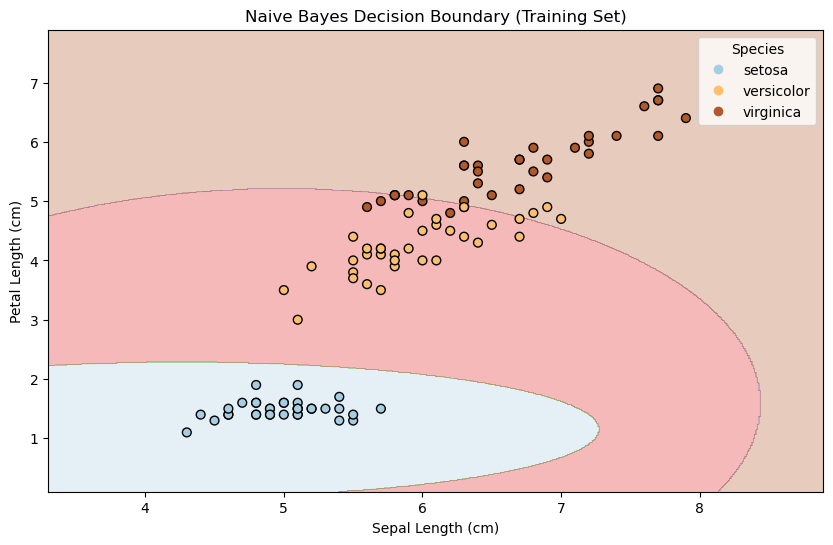

In [19]:
#Plot the decision Boundary
plot_decision_boundary(X_train_vis, y_train_vis, nb_model_vis, 'Naive Bayes Decision Boundary (Training Set)')

## Summary

- **Understanding Naïve Bayes:** Grasped the fundamentals of the Naïve Bayes classifier and its probabilistic approach based on Bayes' Theorem.
- **Implementation:** Successfully implemented the Naïve Bayes classifier using Python's `scikit-learn` library.
- **Application:** Applied the classifier to the Iris dataset and evaluated its performance.
- **Visualization:** Created visualizations to understand data distributions and decision boundaries.